In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
weather_data = pd.read_csv('./weather.csv', low_memory=False)

In [3]:
weather_data.head()

,hour,temp,wind
0,0,73,6wnw
1,1,71,11nw
2,2,70,6nnw
3,3,69,4nnw
4,4,67,2nnw


In [10]:
time = weather_data['hour']
temp = weather_data['temp']

In [151]:
def showplot(y_pred=None):
    plt.scatter(time, temp)
    plt.title('24-hour Temperature in Parker')
    plt.xlabel('Time (hr)')
    plt.ylabel('Temperature (F)')
    if y_pred is not None and len(y_pred) >= 1:
        plt.plot(y_pred, 'r')
    plt.show()

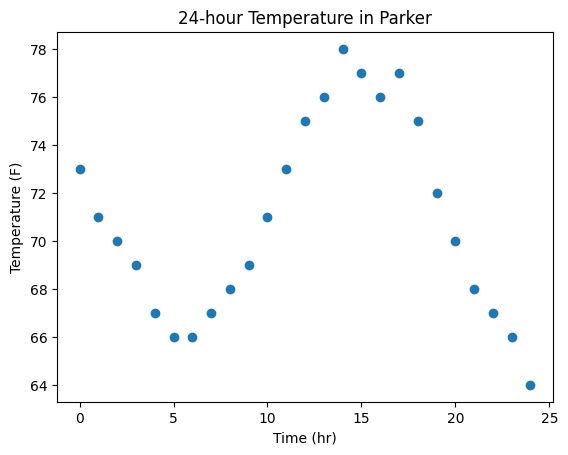

In [152]:
showplot()

In [60]:
ones = np.ones((25,1), dtype=int)
time = np.array(time).reshape(-1, 1)
time_2 = np.square(time).reshape(-1,1)
time_3 = np.array(time**3).reshape(-1,1)
# time_mat = np.array((ones, time, time_2, time_3))

In [61]:
t = np.append(ones, time, axis=1)
t = np.append(t, time_2, axis=1)
t = np.append(t, time_3, axis=1)
t

array([[    1,     0,     0,     0],
       [    1,     1,     1,     1],
       [    1,     2,     4,     8],
       [    1,     3,     9,    27],
       [    1,     4,    16,    64],
       [    1,     5,    25,   125],
       [    1,     6,    36,   216],
       [    1,     7,    49,   343],
       [    1,     8,    64,   512],
       [    1,     9,    81,   729],
       [    1,    10,   100,  1000],
       [    1,    11,   121,  1331],
       [    1,    12,   144,  1728],
       [    1,    13,   169,  2197],
       [    1,    14,   196,  2744],
       [    1,    15,   225,  3375],
       [    1,    16,   256,  4096],
       [    1,    17,   289,  4913],
       [    1,    18,   324,  5832],
       [    1,    19,   361,  6859],
       [    1,    20,   400,  8000],
       [    1,    21,   441,  9261],
       [    1,    22,   484, 10648],
       [    1,    23,   529, 12167],
       [    1,    24,   576, 13824]])

In [100]:
c = np.linalg.inv(t.T@t)@t.T@temp
c

array([ 7.26451282e+01, -2.41430188e+00,  3.29841897e-01, -1.04118104e-02])

In [117]:
# Residuals, x_hat are the predictions
x_hat = t@c
np.sqrt(1/25*np.sum(np.abs(x_hat-temp)))

np.float64(1.1840172755869227)

In [116]:
np.sum(np.abs(x_hat-temp))

np.float64(35.047422722206974)

In [143]:
y_pred = t@c
r = (temp - y_pred)
# np.linalg.norm(r)

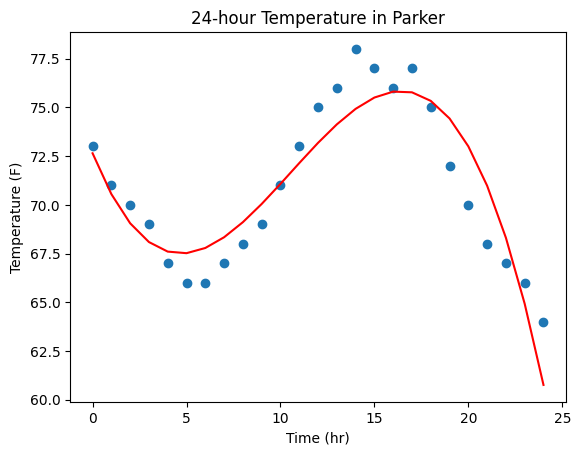

In [153]:
showplot(y_pred)

In [ ]:
def predict_temperature(x):

    b0 =  72.6451282
    b1 =  -2.41430188
    b2 =   0.329841897
    b3 =  -0.0104118104

    return b0 + b1*x + b2*x**2 + b3*x**3


In [155]:
for i in range(25, 48):
    print(predict_temperature(i))

55.75422932500001
49.84842210159999
42.97805624979995
35.080660907199956
26.093765211399983
15.954898300000025
4.601589310599991
-8.028632619200039
-21.99823835180007
-37.36969874959999
-54.20548467500004
-72.56806699040004
-92.51991655820007
-114.12350424080006
-137.44130090059997
-162.53577739999997
-189.46940460140002
-218.3046533672
-249.10399455980007
-281.92989904160004
-316.8448376750001
-353.9112813224002
-393.1917008462001
